# 01. Statistical Thinking for Decision Science

Statistics is often introduced as a collection of formulas. For decision science, that framing is too small. Statistical thinking is the discipline of turning messy operational data into defensible statements about uncertainty, variability, risk, and action.

We use a synthetic seller-support case study. A marketplace operations team is considering whether it can safely promise a premium response standard to high-value sellers. Before anyone makes that promise, the team needs to understand what is being measured, how variable the system is, what can be learned from a sample, and how much uncertainty should remain in the final recommendation.

That is the spirit of the course. We are not doing statistics for its own sake. We are doing statistics because real decisions are made under incomplete evidence.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why statistical analysis begins with a decision question before choosing a model.
2. Distinguish the population, sample, unit of analysis, variables, and outcomes in an operational setting.
3. Use point estimates, quantiles, and rates to summarize a noisy process.
4. Explain why a sample mean or sample rate is uncertain, even when computed correctly.
5. Use repeated sampling and the bootstrap to study the stability of estimates.
6. Show how subgroup composition can change an overall summary.
7. Translate statistical evidence into a professional decision recommendation with explicit uncertainty.

In [11]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Start With the Decision, Not the Formula

A common beginner mistake is to ask, "Which test should I run?" before asking, "What decision is on the table?" Decision science reverses that order.

A useful statistical analysis begins with a practical frame:

- What action might be taken?
- What unit is affected by that action or decision?
- Which outcomes matter enough to track?
- How will uncertainty change the recommendation?
- What counts as good enough to proceed?

Here, the operational decision is not yet causal. We are not asking whether a new support policy *caused* better outcomes. We are asking whether current system performance is strong and stable enough to justify a premium service commitment. That is already a statistical problem.

| Element | Definition |
|---|---|
| Business question | Should the marketplace promise a premium support response standard to priority sellers next quarter? |
| Unit | One seller support ticket |
| Target population | Priority-support tickets expected next quarter across all regions |
| Primary metrics | Mean resolution time, 90th percentile resolution time, SLA breach rate |
| Secondary metric | Average service cost per ticket |
| Risk if wrong | The firm may overpromise service quality, miss SLAs, and damage seller trust |
| Decision rule | Launch only if performance is strong enough and uncertainty is acceptably low |


The table is tied directly to the decision. An analyst has to be able to explain why a summary statistic matters to the business.

Notice what is *not* here. We have not committed to a regression, test statistic, or modeling library. Those are downstream tools. First we clarify the unit, the target population, the outcome, the practical threshold, and the cost of being wrong.

That mindset will keep the rest of the course disciplined. Statistical techniques are only useful when they remain attached to a decision context.

## 2. Population, Sample, and Data-Generating Process

In live work, analysts rarely observe the full population of interest. They observe a sample produced by logging systems, operational constraints, and measurement pipelines.

For teaching purposes, we will simulate a full population of seller-support tickets and then draw an observed sample from it. This gives us a hidden instructor view of the truth. In practice, that truth is unknown, which is exactly why uncertainty quantification matters.

The synthetic data include:

- `seller_tier`: standard, growth, or enterprise;
- `severity`: low, medium, high, or urgent;
- `channel`: chat, email, or phone;
- `region`: geographic operating region;
- `queue_load`: how congested the queue is when the ticket arrives;
- `analyst_experience`: a standardized score for the assigned analyst;
- `resolution_minutes`: time to full resolution;
- `sla_breach`: whether the 60-minute premium threshold is missed;
- `cost_per_ticket`: a simple operational cost proxy.

This is enough structure to study several foundational ideas at once: units, variation, skew, subgroup composition, and the difference between a population quantity and a sample estimate.

In [12]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2026)
n_population = 120_000
sample_size = 1_500
premium_sla_minutes = 60

severity_levels = np.array(["low", "medium", "high", "urgent"])
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
region_levels = np.array(["North", "South", "West", "Central"])
channel_levels = np.array(["chat", "email", "phone"])

seller_tier = rng.choice(seller_tier_levels, size=n_population, p=[0.58, 0.27, 0.15])
severity = rng.choice(severity_levels, size=n_population, p=[0.42, 0.31, 0.19, 0.08])
region = rng.choice(region_levels, size=n_population, p=[0.26, 0.22, 0.29, 0.23])

channel_probability_map = {
    "low": [0.60, 0.30, 0.10],
    "medium": [0.44, 0.36, 0.20],
    "high": [0.22, 0.43, 0.35],
    "urgent": [0.10, 0.35, 0.55],
}

channel = np.empty(n_population, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

region_load_shift = {"North": -0.15, "South": 0.10, "West": 0.20, "Central": 0.00}
queue_load = rng.normal(
    loc=np.vectorize(region_load_shift.get)(region),
    scale=0.80,
    size=n_population,
)
queue_load = np.clip(queue_load, -1.8, 2.8)

analyst_experience = rng.beta(a=3.0, b=2.1, size=n_population)

severity_base = {"low": 14, "medium": 28, "high": 50, "urgent": 74}
channel_effect = {"chat": -4, "email": 1, "phone": 8}
tier_effect = {"standard": -2, "growth": 2, "enterprise": 8}
region_effect = {"North": -1, "South": 2, "West": 1, "Central": 0}

service_noise = rng.gamma(shape=2.3, scale=5.5, size=n_population)

resolution_minutes = (
    np.vectorize(severity_base.get)(severity)
    + np.vectorize(channel_effect.get)(channel)
    + np.vectorize(tier_effect.get)(seller_tier)
    + np.vectorize(region_effect.get)(region)
    + 4.5 * queue_load
    - 6.0 * analyst_experience
    + service_noise
)
resolution_minutes = np.clip(resolution_minutes, 4, None)

sla_breach = (resolution_minutes > premium_sla_minutes).astype(int)
cost_per_ticket = (
    0.85 * resolution_minutes
    + 18.0 * sla_breach
    + 0.08 * np.maximum(resolution_minutes - premium_sla_minutes, 0) ** 1.15
)

population = pd.DataFrame(
    {
        "seller_tier": pd.Categorical(seller_tier, categories=seller_tier_levels, ordered=True),
        "severity": pd.Categorical(severity, categories=severity_levels, ordered=True),
        "channel": pd.Categorical(channel, categories=channel_levels, ordered=True),
        "region": pd.Categorical(region, categories=region_levels, ordered=True),
        "queue_load": queue_load,
        "analyst_experience": analyst_experience,
        "resolution_minutes": resolution_minutes,
        "sla_breach": sla_breach,
        "cost_per_ticket": cost_per_ticket,
    }
)

sample = population.sample(n=sample_size, random_state=17).reset_index(drop=True)


def ticket_metrics(frame):
    """
    Compute the ticket metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
    
    Returns:
        A pandas Series of ticket-level metrics, including sample size, center, tail behavior, breach rate, and cost summaries.
    
    Idea:
        Collect the operational quantities a decision maker would care about, so sampling error can be discussed on multiple business metrics at once.
    """
    resolution = frame["resolution_minutes"]
    return pd.Series(
        {
            "n_tickets": len(frame),
            "mean_resolution_minutes": resolution.mean(),
            "median_resolution_minutes": resolution.median(),
            "p90_resolution_minutes": resolution.quantile(0.90),
            "sla_breach_rate": frame["sla_breach"].mean(),
            "mean_cost_per_ticket": frame["cost_per_ticket"].mean(),
        }
    )


population.shape, sample.shape

((120000, 9), (1500, 9))

### Dataset and Experiment Design

The dataset is a synthetic support-ticket population for an online marketplace. Each row represents a ticket, but the row is generated from a fuller operational story: seller tier, ticket severity, intake channel, queue pressure, analyst experience, and service outcomes all contribute to what we observe.

This design serves two teaching purposes. First, it lets us compare a finite sample with a known population truth, which is something analysts rarely get in real work. Second, it lets us show how the same dataset supports several kinds of statistical thinking: point estimates, distribution summaries, sampling variability, bootstrap uncertainty, subgroup comparisons, and decision thresholds.

The experiment here is therefore not an A/B test. It is an evidence-building exercise. We ask how much a sample can tell us about a larger operating system, how much uncertainty remains, and how a professional recommendation should acknowledge that uncertainty.

## Variable Guide

| Variable | Role | Why It Matters |
|---|---|---|
| `seller_tier` | Segment label | Higher-value sellers typically expect faster support |
| `severity` | Case-mix driver | More severe tickets are harder and slower to resolve |
| `channel` | Intake mode | Channels differ in both complexity and workflow |
| `region` | Operational context | Regions can differ in staffing and queue congestion |
| `queue_load` | Real-time pressure | Congestion affects throughput and tail risk |
| `analyst_experience` | Workforce capability | More experienced analysts usually resolve tickets faster |
| `resolution_minutes` | Primary continuous outcome | Used to judge service reliability |
| `sla_breach` | Binary operational failure | Directly tied to premium service promises |
| `cost_per_ticket` | Economic guardrail | Fast service that is too expensive may not scale |


This setup already contains several ideas that matter in real work.

First, the **population** is the full set of tickets the business cares about. The **sample** is the smaller set of tickets the analyst actually reviews. The population quantity is what the decision should ideally depend on, but the sample is all we have access to.

Second, variables have different roles. Some describe segmentation, some describe context, and some are outcomes. Statistical confusion often starts when those roles are left implicit.

Third, the data-generating process is doing a lot of work behind the scenes. Ticket severity, intake channel, staffing pressure, and analyst experience all influence the observed outcomes. Even before causal inference enters the picture, decision science depends on taking that structure seriously.

## 3. Point Estimates: Useful, Necessary, and Incomplete

A point estimate compresses a sample into a single number. For example, the sample mean resolution time is

$$
\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i
$$

and the sample SLA breach rate is

$$
\hat{p} = \frac{1}{n}\sum_{i=1}^{n} I(y_i > 60)
$$

These summaries are indispensable, but they are not the whole story. A mean can hide skew. A median can hide tail risk. A breach rate can look acceptable overall while masking severe subgroup problems.

We will compare population metrics with sample estimates. Again, the population values are visible only because this is a simulation. They represent the hidden truth that analysts wish they knew.

In [13]:
# Build a summary table that supports the interpretation in the surrounding notes.
population_metrics = ticket_metrics(population)
sample_metrics = ticket_metrics(sample)

metric_labels = {
    "mean_resolution_minutes": "Mean resolution minutes",
    "median_resolution_minutes": "Median resolution minutes",
    "p90_resolution_minutes": "90th percentile resolution minutes",
    "sla_breach_rate": "SLA breach rate",
    "mean_cost_per_ticket": "Mean cost per ticket",
}

metric_comparison = pd.DataFrame(
    {
        "population_truth": population_metrics,
        "sample_estimate": sample_metrics,
    }
)
metric_comparison = metric_comparison.loc[list(metric_labels.keys())].rename(index=metric_labels)
metric_comparison["estimation_error"] = metric_comparison["sample_estimate"] - metric_comparison["population_truth"]

smart_display(metric_comparison)


,population_truth,sample_estimate,estimation_error
Mean resolution minutes,40.509,41.569,1.060
Median resolution minutes,35.313,36.031,0.718
90th percentile resolution minutes,74.751,75.415,0.664
SLA breach rate,0.199,0.209,0.010
Mean cost per ticket,38.464,39.561,1.096


The sample estimates will usually be close to the population values, but not identical. That gap is not a coding error. It is the basic statistical fact that a finite sample contains noise.

A few lessons usually show up immediately:

- The mean is only one summary of performance.
- The median is often lower than the mean in right-skewed service data.
- The 90th percentile can be much more relevant than the mean when a business is about to make a service promise.
- Rates such as the breach rate are often easier for stakeholders to understand than abstract distributional language.

Point estimates are where reporting starts. They are not where responsible reporting ends.

## 4. Distributions Matter Because Tail Risk Matters

Suppose two support systems both average 42 minutes per ticket. One is tightly concentrated around 42. The other resolves many tickets quickly but occasionally takes two hours. Those systems have the same mean and very different operational risk.

Decision science therefore cares about full distributions, including averages, tails, and failure rates. In service operations, high quantiles and failure rates are often more important than the center of the distribution.

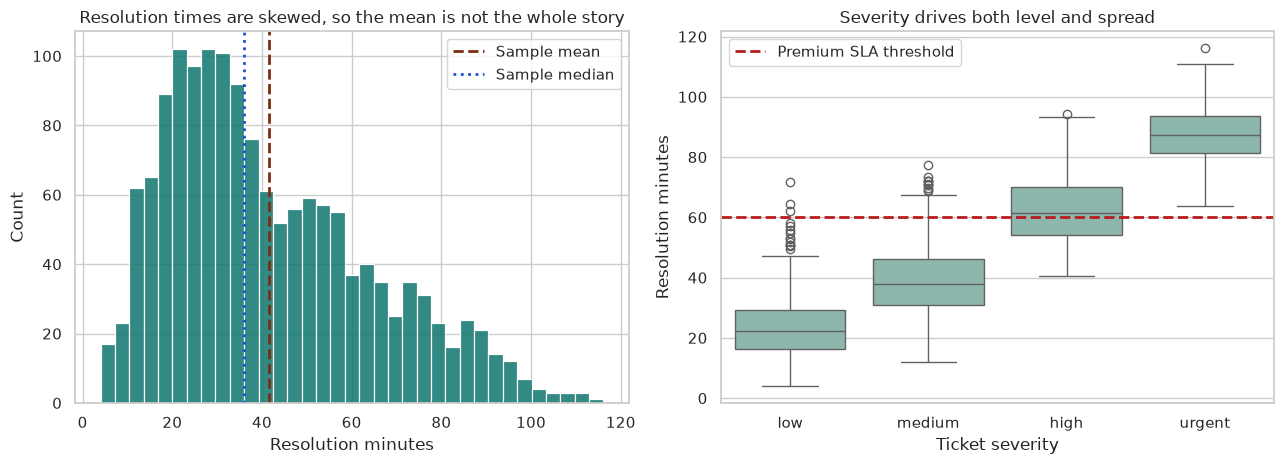

In [14]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(sample, x="resolution_minutes", bins=35, color="#0f766e", alpha=0.85, ax=axes[0])
axes[0].axvline(sample_metrics["mean_resolution_minutes"], color="#7c2d12", linestyle="--", linewidth=2, label="Sample mean")
axes[0].axvline(sample_metrics["median_resolution_minutes"], color="#1d4ed8", linestyle=":", linewidth=2, label="Sample median")
axes[0].set_title("Resolution times are skewed, so the mean is not the whole story")
axes[0].set_xlabel("Resolution minutes")
axes[0].legend()

sns.boxplot(data=sample, x="severity", y="resolution_minutes", color="#86bdb0", ax=axes[1])
axes[1].axhline(premium_sla_minutes, color="#b91c1c", linestyle="--", linewidth=2, label="Premium SLA threshold")
axes[1].set_title("Severity drives both level and spread")
axes[1].set_xlabel("Ticket severity")
axes[1].set_ylabel("Resolution minutes")
axes[1].legend()

plt.tight_layout()
plt.show()


The first panel usually shows a long right tail. That tells us the process occasionally produces very slow resolutions. A premium service promise is exposed to exactly that tail behavior.

The second panel shows that severity changes both the average resolution time and the variability. Urgent tickets are harder, more spread out, and more likely to cross the SLA threshold.

This is an early version of a theme we will revisit: averages can mix together very different operating regimes. An analyst needs to know when the average is informative and when it is hiding the real operational problem.

## 5. Sampling Variability: Why One Sample Is Not the Truth

Even if the logging pipeline is perfect, a sample estimate still varies from sample to sample. The sample mean from one week will not equal the sample mean from another week, even when both are drawn from the same underlying process.

This is the core reason confidence intervals, standard errors, and resampling methods exist. They quantify how much an estimate would move if we repeated the data collection process.

We will study this directly by repeatedly drawing fresh samples from the simulated population.

In [15]:
# Define helper functions so repeated calculations stay readable.
def repeated_sample_metrics(frame, sample_size, n_draws=1000, seed=88):
    """
    Compute the repeated sample metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        sample_size: Sample size or group size used by the simulation, resampling, or inference step.
        n_draws: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of repeated-sample metric estimates used to visualize sampling variability.
    
    Idea:
        Show how operational summaries vary across samples, reinforcing that a dashboard number is one realization of a noisy process.
    """
    local_rng = np.random.default_rng(seed)
    indices = np.arange(len(frame))
    draws = []
    for draw_id in range(n_draws):
        chosen = local_rng.choice(indices, size=sample_size, replace=False)
        metrics = ticket_metrics(frame.iloc[chosen])
        metrics["draw_id"] = draw_id
        draws.append(metrics)
    return pd.DataFrame(draws)


sampling_distribution = repeated_sample_metrics(population, sample_size=sample_size, n_draws=1000)
sampling_distribution.head()

,n_tickets,mean_resolution_minutes,median_resolution_minutes,p90_resolution_minutes,sla_breach_rate,mean_cost_per_ticket,draw_id
0,1500.000,41.019,36.068,75.415,0.205,39.018,0.000
1,1500.000,40.286,35.204,75.010,0.192,38.133,1.000
2,1500.000,39.974,34.844,73.918,0.191,37.845,2.000
3,1500.000,40.993,35.450,75.678,0.199,38.872,3.000
4,1500.000,40.748,34.683,76.419,0.210,38.925,4.000


These repeated samples make the main warning visible. The same data-generating process can produce noticeably different audit summaries. One sample is evidence about the process, not the process itself.


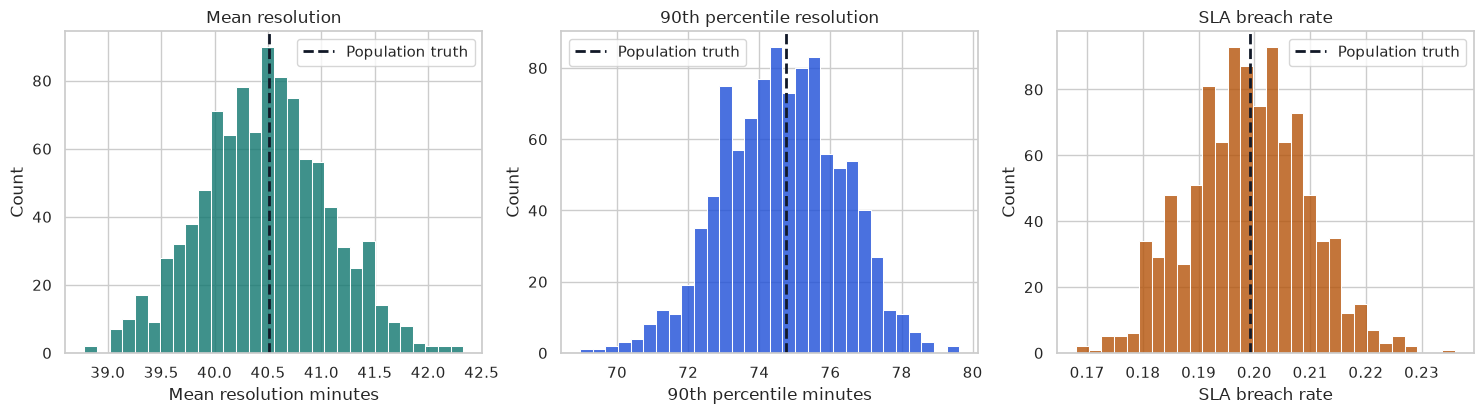

In [16]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

plot_specs = [
    ("mean_resolution_minutes", "Mean resolution", "Mean resolution minutes", "#0f766e"),
    ("p90_resolution_minutes", "90th percentile resolution", "90th percentile minutes", "#1d4ed8"),
    ("sla_breach_rate", "SLA breach rate", "SLA breach rate", "#b45309"),
]

for ax, (column, title, xlabel, color) in zip(axes, plot_specs):
    sns.histplot(sampling_distribution[column], bins=30, color=color, alpha=0.80, ax=ax)
    ax.axvline(population_metrics[column], color="#111827", linestyle="--", linewidth=2, label="Population truth")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()

plt.tight_layout()
plt.show()


These histograms are empirical sampling distributions. Each one shows what the estimate would look like if we repeated the sampling procedure many times.

A few important patterns usually appear:

- The mean is relatively stable because it uses information from all observations.
- The 90th percentile is noticeably noisier because tail quantities depend on fewer effective observations.
- The breach rate can still vary meaningfully, especially if the true rate is near an operational threshold.

This matters for practice. If a launch decision depends on a tail metric, then a large sample and careful uncertainty quantification become especially important.

## 6. Bootstrap Intervals From the Observed Sample

Repeated sampling from the full population is an instructor trick. In live work, we only have the observed sample. A common workaround is the bootstrap: resample rows with replacement from the observed data, recompute the statistic, and use the resulting distribution as an approximation to sampling uncertainty.

The bootstrap is not magic. It does not fix measurement bias, selection bias, or process drift. It only approximates how unstable the statistic is under repeated sampling from the empirical distribution represented by the observed sample.

In [17]:
# Define helper functions so repeated calculations stay readable.
def bootstrap_metrics(frame, n_boot=1500, seed=314):
    """
    Generate bootstrap-based metrics results from resampled data.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        n_boot: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of bootstrap metric estimates for uncertainty around the observed sample.
    
    Idea:
        Use resampling to attach uncertainty to operational summaries so one sample summary is treated as uncertain evidence.
    """
    local_rng = np.random.default_rng(seed)
    indices = np.arange(len(frame))
    draws = []
    for draw_id in range(n_boot):
        chosen = local_rng.choice(indices, size=len(frame), replace=True)
        metrics = ticket_metrics(frame.iloc[chosen])
        metrics["draw_id"] = draw_id
        draws.append(metrics)
    return pd.DataFrame(draws)


bootstrap_draws = bootstrap_metrics(sample)

interval_rows = []
for column, label in metric_labels.items():
    low, high = bootstrap_draws[column].quantile([0.025, 0.975])
    interval_rows.append(
        {
            "metric": label,
            "sample_estimate": sample_metrics[column],
            "bootstrap_ci_low": low,
            "bootstrap_ci_high": high,
        }
    )

bootstrap_interval_table = pd.DataFrame(interval_rows)
smart_display(bootstrap_interval_table)

,metric,sample_estimate,bootstrap_ci_low,bootstrap_ci_high
0,Mean resolution minutes,41.569,40.446,42.759
1,Median resolution minutes,36.031,34.858,37.980
2,90th percentile resolution minutes,75.415,73.202,78.104
3,SLA breach rate,0.209,0.188,0.229
4,Mean cost per ticket,39.561,38.220,40.918


The interval table should change how we talk about the evidence.

A statistically responsible phrasing is closer to: "The observed sample estimate is 41.8 minutes, and plausible values under repeated sampling from similar data fall in a wider interval."

This caution matters in real decisions. Decision-makers often act on a threshold. When the interval overlaps that threshold, the recommendation should usually sound more guarded than the point estimate alone might suggest.

## 7. Heterogeneity and Composition: Why Condition on Subgroups

A global average is a weighted mixture of subgroup averages. If the subgroup mix changes, the overall average changes, even if within-group behavior stays the same.

This is one reason analysts condition on relevant features. Subgroup summaries reveal where performance is genuinely weak and where the overall metric is being driven by composition.

In [18]:
# Build a summary table that supports the interpretation in the surrounding notes.
severity_summary = (
    sample.groupby("severity", observed=True)
    .agg(
        tickets=("resolution_minutes", "size"),
        share=("resolution_minutes", lambda x: len(x) / len(sample)),
        mean_resolution_minutes=("resolution_minutes", "mean"),
        p90_resolution_minutes=("resolution_minutes", lambda x: x.quantile(0.90)),
        sla_breach_rate=("sla_breach", "mean"),
    )
)

smart_display(severity_summary)


,tickets,share,mean_resolution_minutes,p90_resolution_minutes,sla_breach_rate
severity,,,,,
low,608,0.405,23.543,36.434,0.005
medium,457,0.305,38.759,53.386,0.037
high,308,0.205,62.285,76.849,0.542
urgent,127,0.085,87.733,100.629,1.000


The subgroup pattern carries the message. The overall sample mean is useful as a first summary, but severity shows where the operational risk actually lives. Low and medium tickets rarely breach the SLA, while high-severity tickets breach often and urgent tickets breach almost by construction in this sample.

For decision science, this means a single average would lead to a weak recommendation. Staffing, escalation rules, and service promises should be evaluated by severity mix because a change in the mix can move the aggregate metric even if no within-severity process has improved.


In [19]:
# Build a summary table that supports the interpretation in the surrounding notes.
raw_channel_mean = sample.groupby("channel", observed=True)["resolution_minutes"].mean()

overall_severity_weights = sample["severity"].value_counts(normalize=True).sort_index()
channel_by_severity = (
    sample.groupby(["channel", "severity"], observed=True)["resolution_minutes"]
    .mean()
    .unstack()
    .reindex(columns=overall_severity_weights.index)
)

severity_standardized_channel_mean = channel_by_severity.mul(overall_severity_weights, axis=1).sum(axis=1)
channel_comparison = pd.DataFrame(
    {
        "raw_mean_minutes": raw_channel_mean,
        "severity_standardized_mean_minutes": severity_standardized_channel_mean,
    }
).sort_values("raw_mean_minutes")

channel_mix = pd.crosstab(sample["channel"], sample["severity"], normalize="index").round(3)

smart_display(channel_comparison)


,raw_mean_minutes,severity_standardized_mean_minutes
channel,,
chat,29.637,36.577
email,44.552,42.931
phone,59.378,48.323


The raw channel means ask which channel has longer tickets *in the observed mix of cases*. The severity-standardized means ask what channel performance would look like if each channel handled the same severity mix.

That distinction is subtle but important. A channel can look slow partly because it absorbs harder cases. Conditioning and weighting help separate workload composition from pure performance differences.

At this stage, the analysis is descriptive and inferential, with causal reasoning introduced later. But the instinct to ask, "What else is being mixed together here?" is already pointing toward stronger analytical practice.

## 8. Turning Statistical Evidence Into a Recommendation

A professional statistical analysis should end with a recommendation that is explicit about thresholds and uncertainty.

Suppose leadership proposes the following launch standards for a premium service commitment:

- mean resolution time at or below 42 minutes;
- 90th percentile resolution time at or below 78 minutes;
- SLA breach rate at or below 18%.

These thresholds are business rules, not natural laws. Statistics does not choose them automatically. What statistics *can* do is estimate whether current performance seems likely to satisfy them.

In [20]:
# Simulate data or resample observations to study variability and uncertainty.
targets = {
    "mean_resolution_minutes": 42.0,
    "p90_resolution_minutes": 78.0,
    "sla_breach_rate": 0.18,
}

decision_rows = []
for column, target in targets.items():
    ci_low, ci_high = bootstrap_draws[column].quantile([0.025, 0.975])
    prob_meets_target = (bootstrap_draws[column] <= target).mean()
    decision_rows.append(
        {
            "metric": metric_labels[column],
            "sample_estimate": sample_metrics[column],
            "target": target,
            "bootstrap_ci_low": ci_low,
            "bootstrap_ci_high": ci_high,
            "probability_target_met": prob_meets_target,
            "population_truth_simulation_only": population_metrics[column],
        }
    )

decision_table = pd.DataFrame(decision_rows)
joint_probability_all_targets_met = (
    (bootstrap_draws["mean_resolution_minutes"] <= targets["mean_resolution_minutes"])
    & (bootstrap_draws["p90_resolution_minutes"] <= targets["p90_resolution_minutes"])
    & (bootstrap_draws["sla_breach_rate"] <= targets["sla_breach_rate"])
).mean()

recommendation = (
    "Proceed to a premium launch"
    if joint_probability_all_targets_met >= 0.80
    else "Do not promise the premium standard broadly yet; improve operations or gather more evidence first"
)

smart_display(decision_table)
pd.DataFrame(
    [
        {
            "joint_probability_all_targets_met": joint_probability_all_targets_met,
            "recommendation": recommendation,
        }
    ]
)


,metric,sample_estimate,target,bootstrap_ci_low,bootstrap_ci_high,probability_target_met,population_truth_simulation_only
0,Mean resolution minutes,41.569,42.000,40.446,42.759,0.784,40.509
1,90th percentile resolution minutes,75.415,78.000,73.202,78.104,0.971,74.751
2,SLA breach rate,0.209,0.180,0.188,0.229,0.003,0.199


,joint_probability_all_targets_met,recommendation
0,0.003,Do not promise the premium standard broadly ye...


The decision table supports a much more mature recommendation than a raw sample mean would.

A mature recommendation can say something like:

> Based on the observed sample, current performance appears borderline relative to the proposed premium standards. Some point estimates may be near the threshold, but the uncertainty around tail performance and breach risk is large enough that a broad launch would still be risky.

That is statistically honest and operationally useful. It converts numerical evidence into an action recommendation without hiding uncertainty.

In the simulation we also reveal the population truth. That extra column is only for learning. In real work, leaders never get to see that hidden answer, which is why careful uncertainty language is so important.

## 9. Scope of the Analysis

Here we are doing statistical decision support. It is estimating operational quantities, visualizing variability, quantifying uncertainty, and supporting a threshold-based recommendation.

We are **not** doing causal inference yet. A later causal question would ask whether a policy change, staffing intervention, or AI support tool would *improve* these metrics. That future question requires a counterfactual comparison and a design for separating change caused by an intervention from change caused by background differences.

That distinction is healthy:

- statistics helps us summarize and reason under uncertainty;
- causal inference helps us reason about what would happen if we changed the system;
- machine learning helps us forecast, rank, or automate parts of the workflow.

Decision science often needs all three. This course begins by building the statistical foundation first.

## Wrap-Up

The main ideas of the lecture are simple but deep:

1. Start with the decision and the cost of being wrong.
2. Define the unit, population, variables, and outcomes clearly.
3. Use point estimates, but never confuse them with certainty.
4. Inspect distributions because tail risk matters.
5. Treat subgroup composition as part of the problem, not a side detail.
6. End with a recommendation that states uncertainty plainly.

The rest of the course will build from this base. Once these habits are in place, confidence intervals, tests, regression models, and later causal methods become much easier to interpret responsibly.

## References

- Cumming, G., & Fidler, F. (2009). *Confidence intervals*. *Zeitschrift fuer Psychologie / Journal of Psychology*, 217(1), 15-26. [https://doi.org/10.1027/0044-3409.217.1.15](https://doi.org/10.1027/0044-3409.217.1.15)
- Efron, B. (1979). *Bootstrap methods: Another look at the jackknife*. *The Annals of Statistics*, 7(1), 1-26. [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
